# 3F - DHW e Kelvin: o calor acumulado agrega leitura fisica?

**Pergunta especifica.** O DHW (`dhw_cweek_0p5_12w`) acrescenta informacao alem da SSTA/WWV/OHC, e a propagacao dinamica por SSH/SLA sugere ondas de Kelvin nos grandes eventos?

**Objetivo.** Avaliar se o DHW e severidade acumulada/memoria curta e documentar a leitura Hovmoller de SLA/SSH associada a propagacao oeste-leste.

**Justificativa.** DHW nao deve ser confundido com ONI nem com previsor longo. Ele integra calor persistente: HotSpots diarios de SSTA >= +0,5 C, acumulados em 12 semanas, reportados apenas depois de 12 semanas consecutivas acima do limiar.

**Metodologia.** Serie temporal DHW; correlacao lag DHW->SSTA; Hovmoller de SLA local em janelas 1997/98, 2015/16, 2023/24, 2025/26. **Area:** Nino 3.4 e faixa equatorial por longitude.

**Saidas.** `phase3F_dhw_lagcorr.csv`, `phase3F_dhw_serie.png`, `phase3F_hovmoller_ssh_kelvin.png`.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
from nino_brasil.stats.significance import partial_correlation
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday').loc['1993-01-01':]
rows=[]
for tag,col in [('dhw_cweek_0p5_12w (12sem, >=0.5C diario, C-week canonico)','dhw_cweek_0p5_12w')]:
    for h in [4,8,12]:
        fut=w['nino34_ssta'].shift(-h)
        base=pd.DataFrame({'dhw':w[col],'fut':fut,'ssta':w['nino34_ssta'],'wwv':w['wwv'],'ohc':w['ohc_0_300']}).dropna()
        rb=float(np.corrcoef(base['dhw'],base['fut'])[0,1]); pc=partial_correlation(base['dhw'].values,base['fut'].values,controls=base[['ssta','wwv','ohc']].values)
        rows.append({'metrica_dhw':tag,'horizonte_sem':h,'r_bruto':round(rb,3),'r_parcial':round(pc['r'],3),'p_parcial':round(pc['p_effective'],4),'n_eff':round(pc['n_eff'],1)})
red=pd.DataFrame(rows); u.save_table(red,'phase3F_dhw_redundancia.csv',index=False)
print(red.to_string(index=False))
print('\nVEREDITO: dhw_cweek_0p5_12w e a unica metrica DHW da Fase 3; mede calor acumulado recente acima do 0.5C diario local, nao define El Nino e nao substitui validacao preditiva.')


[tabela] data\processed\parquet\statistics\phase3F_dhw_redundancia.csv
                                              metrica_dhw  horizonte_sem  r_bruto  r_parcial  p_parcial  n_eff
dhw_cweek_0p5_12w (12sem, >=0.5C diario, C-week canonico)              4    0.567      0.509     0.0010   38.8
dhw_cweek_0p5_12w (12sem, >=0.5C diario, C-week canonico)              8    0.489      0.452     0.0049   37.1
dhw_cweek_0p5_12w (12sem, >=0.5C diario, C-week canonico)             12    0.383      0.370     0.0254   36.3

VEREDITO: dhw_cweek_0p5_12w e a unica metrica DHW da Fase 3; mede calor acumulado recente acima do 0.5C diario local, nao define El Nino e nao substitui validacao preditiva.


[figura] data\processed\figures\fase3\phase3F_dhw_serie.png


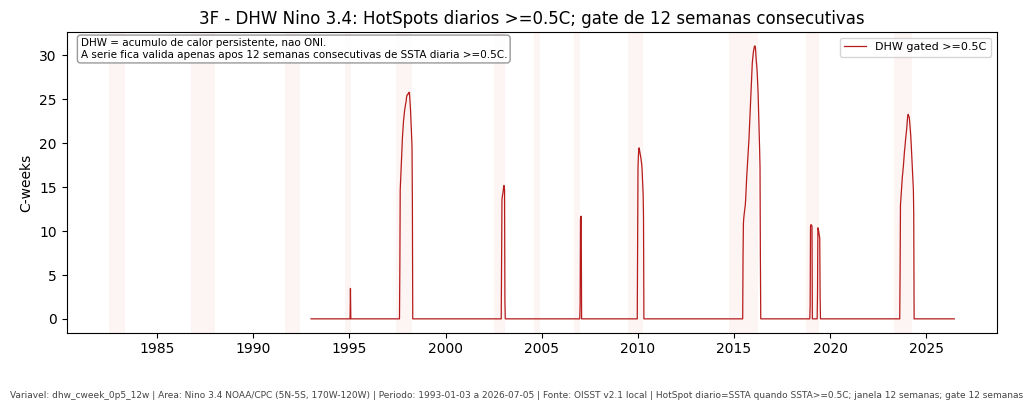

In [2]:
ev = u.load_events()
dhw = w['dhw_cweek_0p5_12w']
fig, ax = plt.subplots(figsize=(12, 3.9))
ax.plot(w.index, dhw, lw=.9, color='#b71c1c', label='DHW gated >=0.5C')
u.add_event_shading(ax, ev, alpha=.18)
ax.set_ylabel('C-weeks')
ax.set_title('3F - DHW Nino 3.4: HotSpots diarios >=0.5C; gate de 12 semanas consecutivas')
ax.legend(fontsize=8)
u.add_note(ax, 'DHW = acumulo de calor persistente, nao ONI.\nA serie fica valida apenas apos 12 semanas consecutivas de SSTA diaria >=0.5C.', loc='upper left')
u.stamp_caption(fig, variavel='dhw_cweek_0p5_12w', area=u.CAIXAS['nino34'], periodo=f'{w.index.min().date()} a {w.index.max().date()}', fonte='OISST v2.1 local', extra='HotSpot diario=SSTA quando SSTA>=0.5C; janela 12 semanas; gate 12 semanas')
u.save_fig(fig, 'phase3F_dhw_serie.png')
plt.show()


[figura] data\processed\figures\fase3\phase3F_hovmoller_ssh_kelvin.png


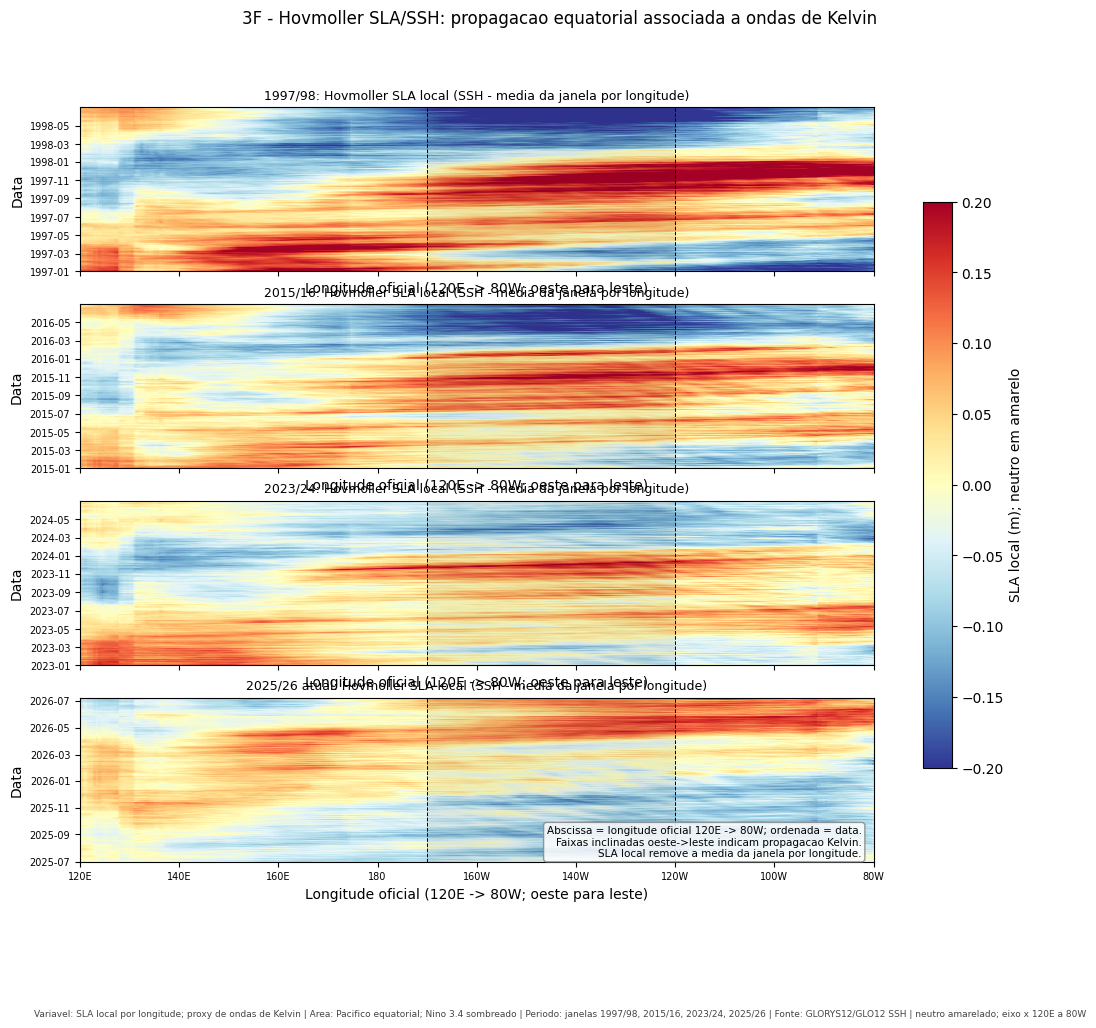

In [3]:
ssh = u.load_ssh_events()
wins = [('1997-01-01','1998-06-30','1997/98'), ('2015-01-01','2016-06-30','2015/16'), ('2023-01-01','2024-06-30','2023/24'), ('2025-07-01',None,'2025/26 atual')]
fig, axes = plt.subplots(len(wins), 1, figsize=(12.8, 9.8), sharex=True)
last_pc = None
for ax, (t0, t1, title) in zip(axes, wins):
    seg = ssh.loc[t0:t1] if t1 else ssh.loc[t0:]
    seg = seg.dropna(how='all')
    if seg.empty:
        ax.text(.5, .5, 'sem dados SSH nesta janela', transform=ax.transAxes, ha='center')
        continue
    lon = seg.columns.values.astype(float)
    sla = seg - seg.mean(axis=0)
    last_pc = ax.pcolormesh(lon, seg.index, sla.values, cmap='RdYlBu_r', vmin=-0.20, vmax=0.20, shading='auto')
    u.add_nino34_lon_band(ax, label=False)
    u.format_lon_axis(ax)
    ax.set_ylabel('Data')
    ax.set_title(f'{title}: Hovmoller SLA local (SSH - media da janela por longitude)', fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle('3F - Hovmoller SLA/SSH: propagacao equatorial associada a ondas de Kelvin')
if last_pc is not None:
    fig.colorbar(last_pc, ax=axes, label='SLA local (m); neutro em amarelo', shrink=.75)
u.add_note(axes[-1], 'Abscissa = longitude oficial 120E -> 80W; ordenada = data.\nFaixas inclinadas oeste->leste indicam propagacao Kelvin.\nSLA local remove a media da janela por longitude.', loc='lower right')
u.stamp_caption(fig, variavel='SLA local por longitude; proxy de ondas de Kelvin', area='Pacifico equatorial; Nino 3.4 sombreado', periodo='janelas 1997/98, 2015/16, 2023/24, 2025/26', fonte='GLORYS12/GLO12 SSH', extra='neutro amarelado; eixo x 120E a 80W')
u.save_fig(fig, 'phase3F_hovmoller_ssh_kelvin.png')
plt.show()


**Leitura do 3F.** `dhw_cweek_0p5_12w` e a unica metrica DHW publica da Fase 3: soma em C-weeks de HotSpots diarios da SSTA Nino 3.4 (`>= +0,5 C`) numa janela de 12 semanas, mas reportada so depois de 12 semanas consecutivas acima do limiar. A figura Kelvin usa SLA local como anomalia de SSH dentro da janela; faixas inclinadas de oeste para leste sao a assinatura esperada de propagacao equatorial. A leitura e diagnostica, nao uma deteccao automatica formal de onda de Kelvin.
